# ViT+K-Fold

In [1]:
import matplotlib.pyplot as plt
import torch
import torchvision
from torch import nn
from torchvision import transforms
from torchvision import transforms, datasets 
from sklearn.model_selection import StratifiedKFold
from helper_functions import set_seeds
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from torchinfo import summary
from going_modular.going_modular import engine
import numpy as np

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [4]:
# 1. Get pretrained weights for ViT-Base
pretrained_vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT 

# 2. Setup a ViT model instance with pretrained weights
pretrained_vit = torchvision.models.vit_b_16(weights=pretrained_vit_weights).to(device)

# 3. Freeze the base parameters
for parameter in pretrained_vit.parameters():
    parameter.requires_grad = False
    
# 4. Change the classifier head 
class_names = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

set_seeds()
pretrained_vit.heads = nn.Linear(in_features=768, out_features=len(class_names)).to(device)

In [5]:
# Print a summary using torchinfo (uncomment for actual output)
summary(model=pretrained_vit, 
        input_size=(32, 3, 224, 224), # (batch_size, color_channels, height, width)
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [32, 3, 224, 224]    [32, 26]             768                  Partial
├─Conv2d (conv_proj)                                         [32, 3, 224, 224]    [32, 768, 14, 14]    (590,592)            False
├─Encoder (encoder)                                          [32, 197, 768]       [32, 197, 768]       151,296              False
│    └─Dropout (dropout)                                     [32, 197, 768]       [32, 197, 768]       --                   --
│    └─Sequential (layers)                                   [32, 197, 768]       [32, 197, 768]       --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [32, 197, 768]       [32, 197, 768]       (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [32, 197, 768]       [32, 

In [16]:
# Setup directory paths to train and test images
train_dir = r"C:\D\D DRIVE\isl alphabets(muskan)\ISL Augmentation\train"
test_dir = r"C:\D\D DRIVE\isl alphabets(muskan)\ISL Augmentation\val"

In [17]:
# Get automatic transforms from pretrained ViT weights
pretrained_vit_transforms = pretrained_vit_weights.transforms()
print(pretrained_vit_transforms)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [18]:
# Load the sample image
sample_image_dataset = datasets.ImageFolder(train_dir, transform=pretrained_vit_transforms)
image, label = sample_image_dataset[0]  # Load the first image and its label

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..-1.4210021].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781574..-1.3512855].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7925336..0.15968838].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7411594..0.3651854].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5699118..-1.0549891].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.552

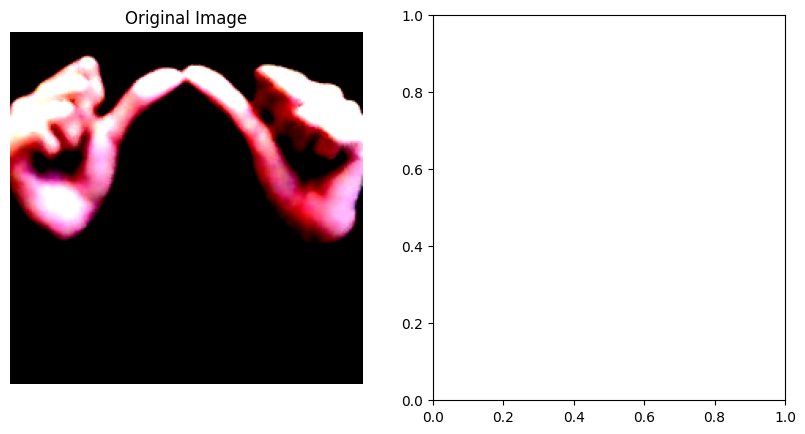

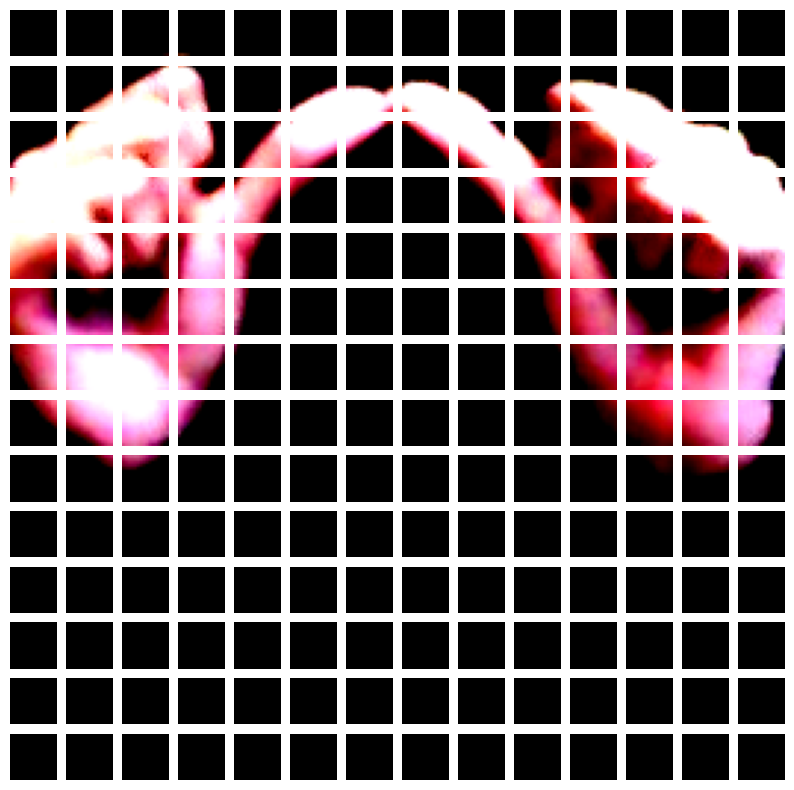

In [19]:
# Function to display patches
def show_image_patches(image, patch_size=16):
    # Convert the image tensor to a NumPy array for display
    image_np = np.transpose(image.numpy(), (1, 2, 0))  # Convert (C, H, W) -> (H, W, C)
    
    # Display the original image
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(image_np)
    ax[0].set_title('Original Image')
    ax[0].axis('off')

    # Divide the image into patches
    img_h, img_w = image_np.shape[:2]
    patches = []

    for i in range(0, img_h, patch_size):
        for j in range(0, img_w, patch_size):
            patch = image_np[i:i+patch_size, j:j+patch_size, :]
            patches.append(patch)

    # Create a grid of patches for visualization
    num_patches_side = img_h // patch_size
    fig_patches, axs = plt.subplots(num_patches_side, num_patches_side, figsize=(10, 10))

    for i in range(num_patches_side):
        for j in range(num_patches_side):
            axs[i, j].imshow(patches[i * num_patches_side + j])
            axs[i, j].axis('off')

    plt.show()

# Show the image divided into patches
show_image_patches(image, patch_size=16)

In [20]:
#Load the ImageFolder dataset
train_dataset = datasets.ImageFolder(train_dir, transform=pretrained_vit_transforms)

In [ ]:
def stratified_kfold(train_dataset, num_folds, batch_size, pretrained_vit_transforms, num_epochs, device):
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

    fold_train_accuracies = []
    fold_val_accuracies = []  # Ensure this list is ready to collect accuracies

    for fold, (train_idx, test_idx) in enumerate(skf.split(train_dataset, train_dataset.targets)):
        print(f"Fold {fold + 1}/{num_folds}")
        print("----------")

        train_sampler = torch.utils.data.SubsetRandomSampler(train_idx)
        test_sampler = torch.utils.data.SubsetRandomSampler(test_idx)

        train_loader = torch.utils.data.DataLoader(
            train_dataset, batch_size=batch_size, sampler=train_sampler
        )
        test_loader = torch.utils.data.DataLoader(
            train_dataset, batch_size=batch_size, sampler=test_sampler
        )

        pretrained_vit = torchvision.models.vit_b_16(weights=pretrained_vit_weights).to(device)
        for parameter in pretrained_vit.parameters():
            parameter.requires_grad = False
        pretrained_vit.heads = nn.Linear(in_features=768, out_features=len(class_names)).to(device)

        optimizer = torch.optim.Adam(params=pretrained_vit.parameters(), lr=1e-3)
        loss_fn = torch.nn.CrossEntropyLoss()

        results = engine.train(
            model=pretrained_vit,
            train_dataloader=train_loader,
            test_dataloader=test_loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            epochs=num_epochs,
            device=device,
        )

        fold_train_accuracies.append(results.get("train_acc", []))
        fold_val_accuracies.append(results.get("val_acc", []))  # Use .get to avoid KeyError

    return fold_train_accuracies, fold_val_accuracies

# Call the stratified k-fold function with the dataset instance
fold_train_accuracies, fold_val_accuracies = stratified_kfold(
    train_dataset=train_dataset,
    num_folds=5,
    batch_size=32,
    pretrained_vit_transforms=pretrained_vit_transforms,
    num_epochs=10,
    device=device,
)

Fold 1/5
----------


  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
from sklearn.metrics import accuracy_score

def stratified_kfold(train_dataset, num_folds, batch_size, pretrained_vit_transforms, num_epochs, device):
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)
    best_fold_accuracy = 0
    best_fold_results = None
    best_fold_confusion_matrix = None

    for fold, (train_idx, test_idx) in enumerate(skf.split(train_dataset, train_dataset.targets)):
        print(f"Fold {fold + 1}/{num_folds}")
        print("----------")

        train_sampler = torch.utils.data.SubsetRandomSampler(train_idx)
        test_sampler = torch.utils.data.SubsetRandomSampler(test_idx)

        train_loader = torch.utils.data.DataLoader(
            train_dataset, batch_size=batch_size, sampler=train_sampler
        )
        test_loader = torch.utils.data.DataLoader(
            train_dataset, batch_size=batch_size, sampler=test_sampler
        )

        pretrained_vit = torchvision.models.vit_b_16(weights=pretrained_vit_weights).to(device)
        for parameter in pretrained_vit.parameters():
            parameter.requires_grad = False
        pretrained_vit.heads = nn.Linear(in_features=768, out_features=len(class_names)).to(device)

        optimizer = torch.optim.Adam(params=pretrained_vit.parameters(), lr=1e-3)
        loss_fn = torch.nn.CrossEntropyLoss()

        pretrained_vit_results = engine.train(
            model=pretrained_vit,
            train_dataloader=train_loader,
            test_dataloader=test_loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            epochs=num_epochs,
            device=device,
        )

        # Calculate test accuracy
        y_true = []
        y_pred = []

        pretrained_vit.eval()
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = pretrained_vit(images)
                _, preds = torch.max(outputs, 1)
                y_true.extend(labels.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())

        fold_accuracy = accuracy_score(y_true, y_pred)
        print(f"Fold {fold + 1} accuracy: {fold_accuracy:.4f}")

        if fold_accuracy > best_fold_accuracy:
            best_fold_accuracy = fold_accuracy
            best_fold_results = pretrained_vit_results
            best_fold_confusion_matrix = confusion_matrix(y_true, y_pred)

    return best_fold_accuracy, best_fold_results, best_fold_confusion_matrix


In [ ]:
# Call the stratified k-fold function with the dataset instance
best_fold_accuracy, best_fold_results, best_fold_confusion_matrix = stratified_kfold(
    train_dataset=train_dataset,
    num_folds=5,
    batch_size=32,
    pretrained_vit_transforms=pretrained_vit_transforms,
    num_epochs=10,
    device=device,
)

# Plotting the training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(best_fold_results['train_acc'], label='Train Accuracy')
plt.plot(best_fold_results['test_acc'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title(f'Training and Validation Accuracy for Best Fold (Accuracy: {best_fold_accuracy:.4f})')
plt.legend()
plt.show()

In [ ]:
# Plot the training and validation accuracy for each fold
for fold in range(len(fold_train_accuracies)):
    plt.plot(fold_train_accuracies[fold], label=f'Training Fold {fold + 1}')
    plt.plot(fold_val_accuracies[fold], label=f'Validation Fold {fold + 1}')

plt.title('Training and Validation Accuracy per Fold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
!pip install seaborn

In [ ]:
import torch
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
y_true = []  # to store true labels
y_pred = []  # to store predicted labels

In [ ]:
print("y_true:", y_true)
print("y_pred:", y_pred)

In [ ]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms

# Define your test directory (update with the correct path)
test_dir = r"D:\D DRIVE\isl alphabets(muskan)\ISL Augmentation\val"

# Define the transformations for the test dataset (resize, normalize, etc.)
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize all images to 224x224
    transforms.ToTensor(),          # Convert images to tensor
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Normalization
])

# Load the test dataset using ImageFolder
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transforms)

# Print the class names and number of classes
print("Class names:", test_dataset.classes)
print("Number of classes:", len(test_dataset.classes))


In [ ]:
print("Class names:", test_dataset.classes)
print("Number of classes:", len(test_dataset.classes))

In [ ]:
print(classification_report(y_true, y_pred, labels=range(len(test_dataset.classes)), target_names=test_dataset.classes, zero_division=1))

In [ ]:
import os
import cv2
import torch
import torch.nn.functional as F
import time
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix

# Define the path to the folder containing test images
test_images_folder = r"D:\realtimeISL"

# Ensure the folder path exists
if not os.path.exists(test_images_folder):
    print(f"Error: The folder '{test_images_folder}' does not exist.")
else:
    print(f"Testing images from folder: {test_images_folder}")

# Define the same transformation used during training
real_time_transform = pretrained_vit_weights.transforms()

# Function to test model on images and plot confusion matrix
def test_with_confusion_matrix(model, image_folder, device, class_names):
    model.eval()  # Set model to evaluation mode
    
    class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}

    correct_predictions = 0
    total_images = 0
    total_inference_time = 0.0

    y_true = []  # True labels
    y_pred = []  # Predicted labels

    # Loop through each class folder
    for class_folder in os.listdir(image_folder):
        class_path = os.path.join(image_folder, class_folder)

        if not os.path.isdir(class_path):
            continue  # Skip non-folder files

        image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        print(f"Testing {len(image_files)} images from class '{class_folder}'.")

        for image_file in image_files:
            image_path = os.path.join(class_path, image_file)
            
            try:
                # Load and transform image
                image = Image.open(image_path).convert("RGB")
                transformed_image = real_time_transform(image).unsqueeze(0).to(device)

                # Measure inference time
                start_time = time.time()
                with torch.no_grad():
                    outputs = model(transformed_image)
                    probabilities = F.softmax(outputs, dim=1)  # Convert logits to probabilities
                    confidence, predicted = torch.max(probabilities, 1)  # Get highest probability and class index
                end_time = time.time()

                inference_time = end_time - start_time
                total_inference_time += inference_time

                predicted_class = class_names[predicted.item()]
                confidence_score = confidence.item() * 100  # Convert to percentage

                # Store true and predicted labels
                if class_folder in class_to_idx:
                    y_true.append(class_to_idx[class_folder])  # True label
                    y_pred.append(predicted.item())  # Predicted label

                # Compare prediction with actual class
                actual_class = class_folder
                is_correct = (predicted_class == actual_class)

                if is_correct:
                    correct_predictions += 1
                
                total_images += 1

                # Print result with confidence score and inference time
                print(f"Image: {image_file} --> Predicted: {predicted_class} ({confidence_score:.2f}%), "
                      f"Actual: {actual_class}, Correct: {is_correct}, Inference Time: {inference_time:.4f} sec")

                # Display image with prediction and confidence score
                img = cv2.imread(image_path)
                img = cv2.resize(img, (400, 400))  # Resize for better visualization

                label_text = f"{predicted_class} ({confidence_score:.1f}%)"
                cv2.putText(img, label_text, (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
                cv2.putText(img, f"{inference_time:.3f}s", (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

                cv2.imshow("Prediction", img)
                cv2.waitKey(500)  # Display each image for 0.5 seconds

            except Exception as e:
                print(f"Error processing image {image_file}: {e}")

    cv2.destroyAllWindows()

    # Compute accuracy
    if total_images > 0:
        accuracy = (correct_predictions / total_images) * 100
        avg_inference_time = total_inference_time / total_images
        print(f"\nTest Accuracy: {accuracy:.2f}% ({correct_predictions}/{total_images} correct)")
        print(f"Average Inference Time per Image: {avg_inference_time:.4f} sec")

        # Compute Precision, Recall, and F1-score
        print("\nClassification Report:\n")
        print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

        # Compute confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=class_names, yticklabels=class_names)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()

    else:
        print("\nNo images found for testing.")

# Run testing on folder images and plot confusion matrix
test_with_confusion_matrix(pretrained_vit, test_images_folder, device, class_names)